# CRM-анализ клиентской базы банка

## Цель проекта
Провести анализ клиентской базы банка, выявить факторы клиентского оттока и определить сегменты для CRM-кампаний.

## Используемые инструменты
- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

# Загрузка и изучение данных

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Bank Customer Churn Prediction.csv")

df.head()


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


# Первичный анализ данных

In [5]:
df.describe()


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df['churn'].value_counts()


churn
0    7963
1    2037
Name: count, dtype: int64

In [7]:
df['churn'].value_counts(normalize=True) * 100

churn
0    79.63
1    20.37
Name: proportion, dtype: float64

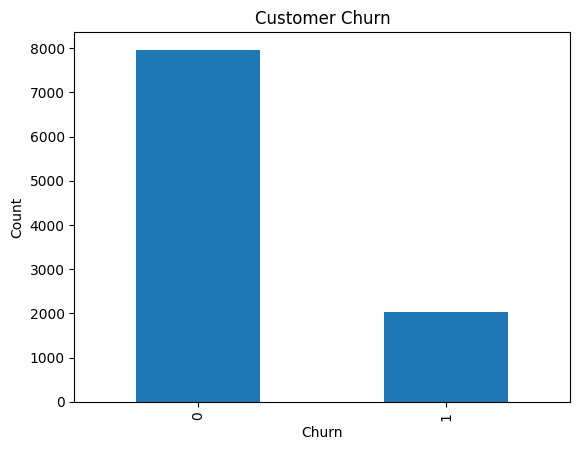

In [8]:
df['churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Count')

plt.show()

# Анализ факторов клиентского оттока

In [9]:
df.groupby('churn')['age'].mean()


churn
0    37.408389
1    44.837997
Name: age, dtype: float64

In [10]:
df.groupby('churn')['balance'].mean()


churn
0    72745.296779
1    91108.539337
Name: balance, dtype: float64

In [11]:
df.groupby('churn')['active_member'].mean()

churn
0    0.554565
1    0.360825
Name: active_member, dtype: float64

In [12]:
df.groupby('churn')['products_number'].mean()

churn
0    1.544267
1    1.475209
Name: products_number, dtype: float64

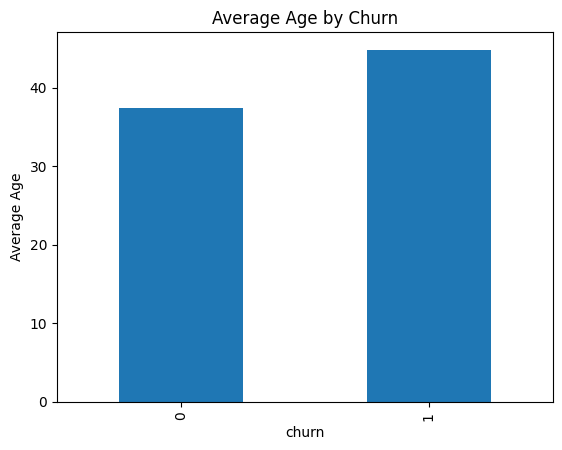

In [13]:
df.groupby('churn')['age'].mean().plot(kind='bar')

plt.title('Average Age by Churn')
plt.ylabel('Average Age')

plt.show()

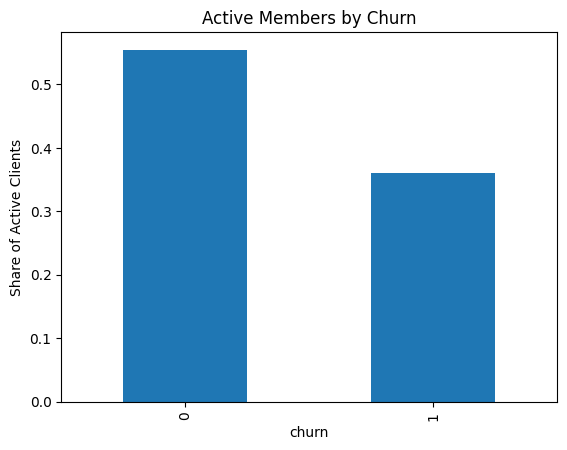

In [14]:
df.groupby('churn')['active_member'].mean().plot(kind='bar')

plt.title('Active Members by Churn')
plt.ylabel('Share of Active Clients')

plt.show()

# Сегментация клиентов

In [15]:
def segment_client(row):

    if row['balance'] > 120000:
        return 'VIP'

    elif row['active_member'] == 0:
        return 'At Risk'

    elif row['products_number'] >= 2:
        return 'Active'

    else:
        return 'Standard'


df['segment'] = df.apply(segment_client, axis=1)

In [16]:
df['segment'].value_counts()

segment
At Risk     3290
VIP         3181
Active      2005
Standard    1524
Name: count, dtype: int64

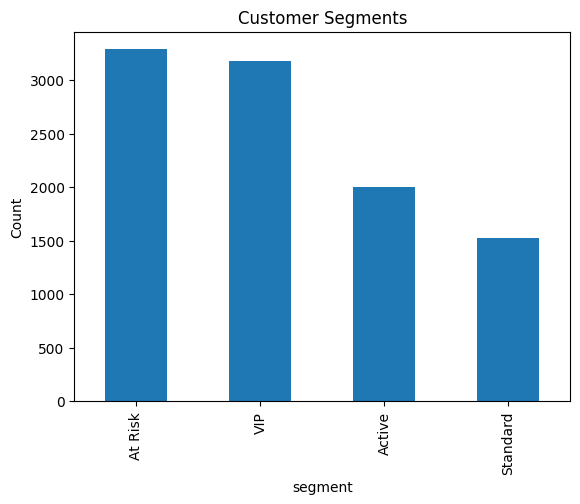

In [17]:
df['segment'].value_counts().plot(kind='bar')

plt.title('Customer Segments')
plt.ylabel('Count')

plt.show()

In [18]:
segment_churn = df.groupby('segment')['churn'].mean() * 100

segment_churn

segment
Active       7.680798
At Risk     24.863222
Standard    19.685039
VIP         24.049041
Name: churn, dtype: float64

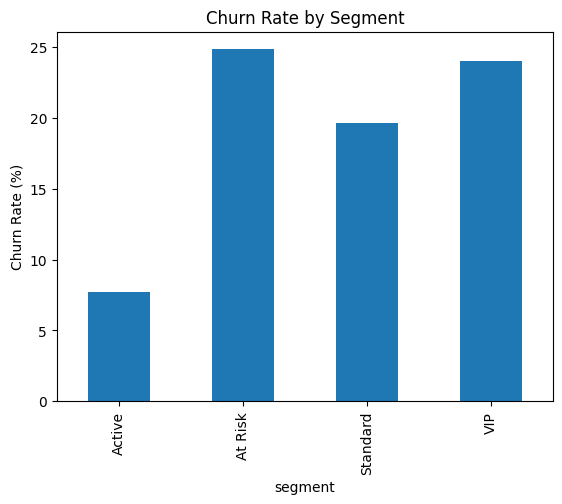

In [19]:
segment_churn.plot(kind='bar')

plt.title('Churn Rate by Segment')
plt.ylabel('Churn Rate (%)')

plt.show()

# CRM-рекомендации

## 1. Сегмент At Risk
Клиенты с низкой активностью демонстрируют самый высокий уровень оттока.

Рекомендуемые действия:
- реактивационные CRM-кампании,
- персонализированные предложения,
- коммуникации по удержанию клиентов.

## 2. VIP-клиенты
VIP-клиенты также показывают высокий уровень оттока несмотря на высокий баланс.

Рекомендуемые действия:
- премиальные предложения,
- персонализированное сопровождение клиентов,
- программы лояльности.

## 3. Активные клиенты
Активные клиенты имеют самый низкий уровень оттока.

Рекомендуемые действия:
- кросс-продажи дополнительных банковских продуктов,
- upsell-кампании,
- развитие продуктового проникновения.

# Заключение

В ходе анализа были выявлены основные факторы, связанные с клиентским оттоком:

- неактивные клиенты чаще покидают банк;
- ушедшие клиенты в среднем старше;
- клиенты с низким уровнем продуктового вовлечения демонстрируют более высокий уровень оттока.

Сегментация клиентской базы позволила определить целевые группы для CRM-кампаний и мероприятий по удержанию клиентов.

Результаты анализа могут быть использованы для повышения уровня удержания клиентов и увеличения продуктового проникновения.